# Bank Customer Churn Prediction - Methodological Approach

**Research Questions:**

RQ1: What customer characteristics have predictive value for identifying churn risk?

RQ2: What is the financial exposure represented by customers identified as high-churn risk?

RQ3: Given assumed intervention costs and success rates, what decision threshold maximizes expected net benefit of targeted retention efforts?


**Objective:** Build a machine learning model to predict customer churn and quantify financial risk.

**Methodological Framework:**

This analysis follows a structured machine learning workflow with explicit justification for each methodological choice:

1. **Data Preparation**: Feature encoding and scaling tailored to algorithm requirements
2. **Exploratory Analysis**: Statistical validation to move beyond descriptive patterns
3. **Model Selection**: Comparison across algorithmic families (linear vs tree-based)
4. **Validation Design**: Proper cross-validation to avoid data leakage
5. **Model Calibration**: Probability adjustment for business decision-making
6. **Feature Interpretation**: Distinguishing prediction from causation
7. **Financial Analysis**: Cost-benefit framework with explicit assumptions



## 1. Data Analysis - Set up and Data Loading

In [116]:
# Required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed for reproducibility
np.random.seed(7)


In [117]:
import os
print("Files in /content/:")
print(os.listdir('/content/'))

Files in /content/:
['.config', 'figure_05_categorical_churn_rates.png', 'figure_04_numeric_distributions_by_churn.png', 'figure_09_feature_importance.png', 'figure_11_threshold_optimization.png', 'Customer-Churn-Records.csv', 'figure_02_correlation_matrix.png', 'figure_06_financial_exposure_analysis.png', 'figure_10_financial_exposure.png', 'figure_07_calibration_curve.png', 'sample_data']


In [118]:
# Load the dataset
df = pd.read_csv('Customer-Churn-Records.csv')

print(f"Dataset has {df.shape[0]} rows and {df.shape[1]} columns")
df.head()

Dataset has 10000 rows and 18 columns


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


In [119]:
# Basic data quality check
missing = df.isnull().sum()
if missing.sum() == 0:
    print("No missing values")
else:
    print(missing[missing > 0])

print(f"Duplicates: {df.duplicated().sum()}")
print(f"Unique customers: {df['CustomerId'].nunique()}")

No missing values
Duplicates: 0
Unique customers: 10000


In [120]:
# Define feature categories for analysis
# Features to exclude from analysis (identifiers, not predictive)
id_features = ['RowNumber', 'CustomerId', 'Surname']

# Numeric features for correlation and statistical analysis
numeric_features = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
                   'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
                   'Complain', 'Satisfaction Score', 'Point Earned']

# Categorical features
categorical_features = ['Geography', 'Gender', 'Card Type']

# Target variable
target = 'Exited'

## 2. Data Analysis - Class Distribution Analysis

Understanding the target variable distribution is critical for:
- Determining appropriate evaluation metrics
- Selecting imbalance handling strategies
- Setting realistic performance expectations

Retained: 7962 (79.62%)
Churned: 2038 (20.38%)
Ratio: 3.91:1


Text(0.5, 1.0, 'Customer Churn Proportion')

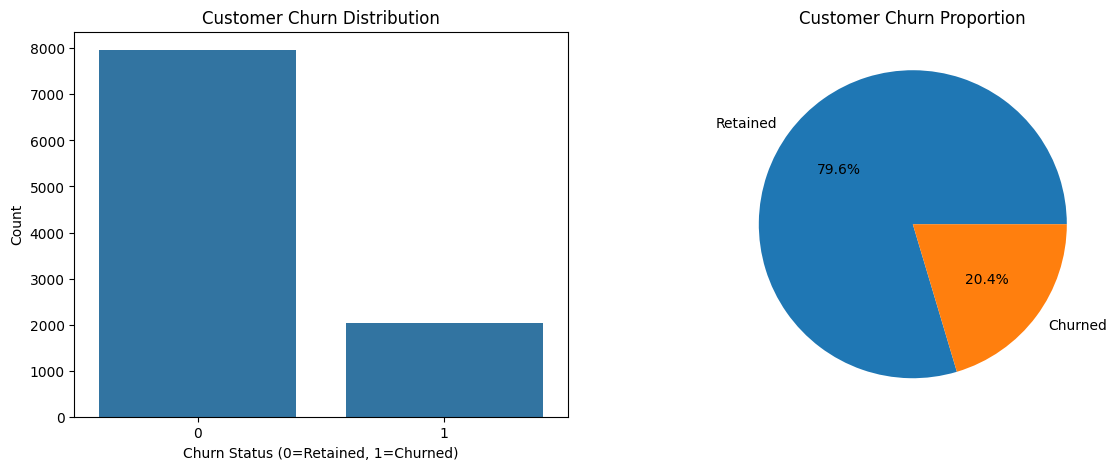

In [121]:
# Analyze target variable distribution
churn_counts = df[target].value_counts()
churn_percent = (df[target].value_counts(normalize=True) * 100).round(2)

print(f"Retained: {churn_counts[0]} ({churn_percent[0]}%)")
print(f"Churned: {churn_counts[1]} ({churn_percent[1]}%)")
print(f"Ratio: {round(churn_counts[0]/churn_counts[1], 2)}:1")

# Plot to show churn visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
sns.countplot(data=df, x=target, ax=axes[0])
axes[0].set_title('Customer Churn Distribution')
axes[0].set_xlabel('Churn Status (0=Retained, 1=Churned)')
axes[0].set_ylabel('Count')

# Pie chart
axes[1].pie(churn_counts, labels=['Retained', 'Churned'], autopct='%1.1f%%')
axes[1].set_title('Customer Churn Proportion')


**Interpretation (Figure 1):**

The churn rate of approximately 20% represents a meaningful but manageable class imbalance.

- **Modeling Strategy**: While not severely imbalanced, this distribution means that a naive model predicting "no churn" for all customers would achieve 80% accuracy but miss all churners entirely.

- **Evaluation Metrics**: Accuracy alone will be insufficient. The analysis will prioritize recall (capturing true churners) and F1-score (balancing precision and recall) when evaluating models.

- **Imbalance Handling**: The analysis will evaluate different strategies (baseline, class weights, and resampling techniques) to determine the most appropriate approach for the 20/80 class distribution.


- **Business Context**: A 20% churn rate indicates significant customer attrition that warrants proactive intervention strategies.

# 3. Data Analysis - Descriptive Statistics

Comprehensive statistical summary to understand feature distributions and identify potential outliers.

In [122]:
# Generate detailed descriptive statistics for Numeric Features
desc_stats = df[numeric_features].describe().T
# Add columns for variance (how spread the data is), skewness (how balanced data is), and kurtosis (peak or flat data)
desc_stats['variance'] = df[numeric_features].var()
desc_stats['skewness'] = df[numeric_features].skew()
desc_stats['kurtosis'] = df[numeric_features].kurtosis()

# Display variance without scientific notation
pd.options.display.float_format = '{:.2f}'.format

desc_stats.round(2)

,count,mean,std,min,25%,50%,75%,max,variance,skewness,kurtosis
CreditScore,10000.00,650.53,96.65,350.00,584.00,652.00,718.00,850.00,9341.86,-0.07,-0.43
Age,10000.00,38.92,10.49,18.00,32.00,37.00,44.00,92.00,109.99,1.01,1.40
Tenure,10000.00,5.01,2.89,0.00,3.00,5.00,7.00,10.00,8.36,0.01,-1.17
Balance,10000.00,76485.89,62397.41,0.00,0.00,97198.54,127644.24,250898.09,3893436175.99,-0.14,-1.49
NumOfProducts,10000.00,1.53,0.58,1.00,1.00,1.00,2.00,4.00,0.34,0.75,0.58
HasCrCard,10000.00,0.71,0.46,0.00,0.00,1.00,1.00,1.00,0.21,-0.90,-1.19
IsActiveMember,10000.00,0.52,0.50,0.00,0.00,1.00,1.00,1.00,0.25,-0.06,-2.00
EstimatedSalary,10000.00,100090.24,57510.49,11.58,51002.11,100193.92,149388.25,199992.48,3307456784.13,0.00,-1.18
Complain,10000.00,0.20,0.40,0.00,0.00,0.00,0.00,1.00,0.16,1.47,0.15
Satisfaction Score,10000.00,3.01,1.41,1.00,2.00,3.00,4.00,5.00,1.98,-0.01,-1.29


In [123]:
# Identify features with high skewness (skew > 1 or skew < -1)
# Check both right-skewed (positive) and left-skewed (negative)
right_skewed = desc_stats['skewness'] > 1
left_skewed = desc_stats['skewness'] < -1
high_skew = desc_stats[right_skewed | left_skewed]['skewness']

if high_skew.empty:
    print("No features with extreme skewness")
else:
    for feature, skew_val in high_skew.items():
        direction = "right-skewed" if skew_val > 0 else "left-skewed"
        print(f"{feature}: {round(skew_val, 3)} ({direction})")

Age: 1.011 (right-skewed)
Complain: 1.466 (right-skewed)


# 4. Data Analysis - Correlation Analysis

**Objective**: Identify relationships between numeric features to:
- Understand feature relationships with the target variable
- Inform feature selection decisions

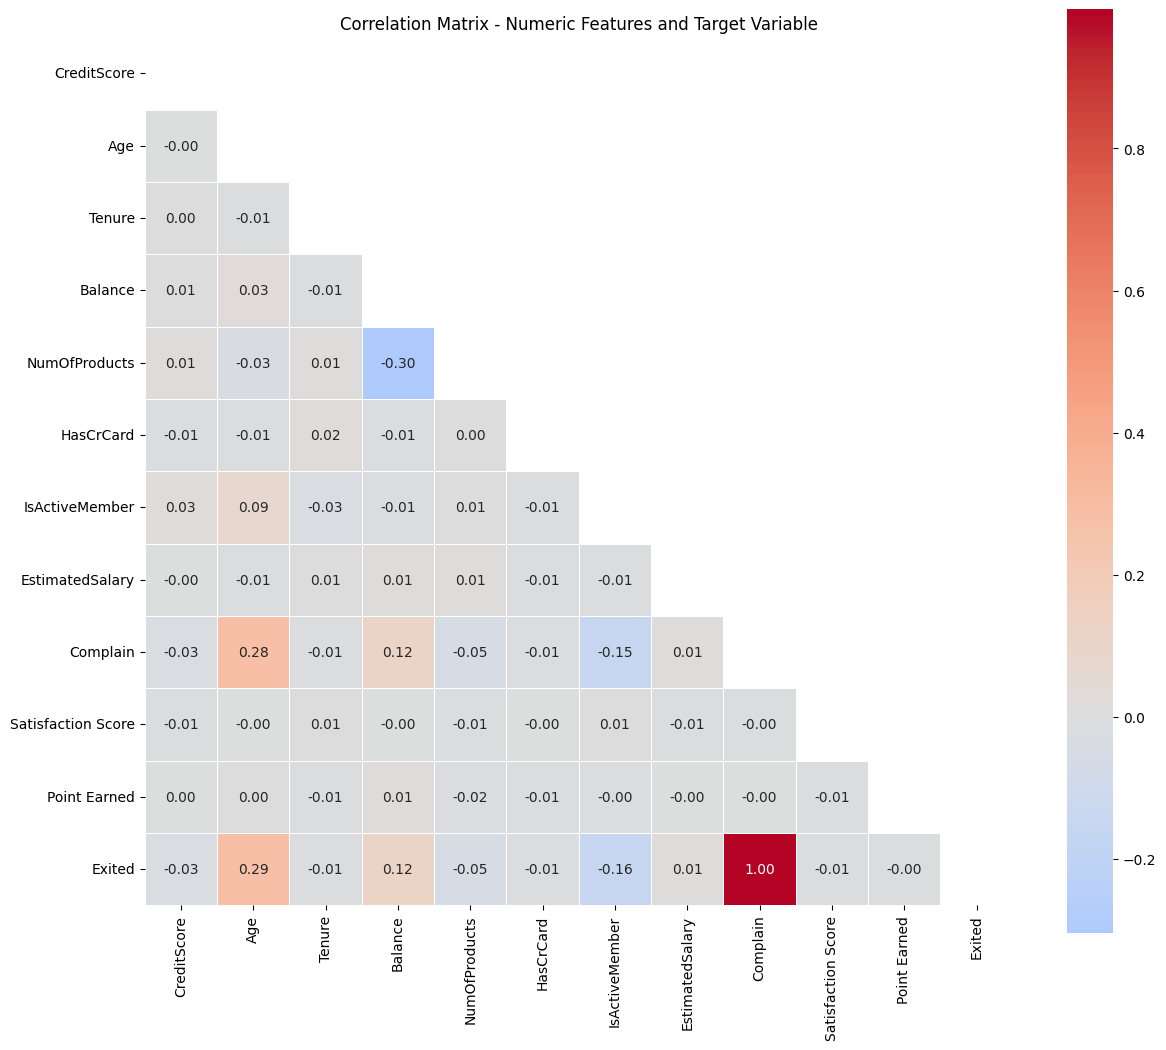

In [124]:
# Calculate correlation matrix - combine list of numaeric features and target feature, calculate corr between columns
corr_features = numeric_features + [target]
correlation_matrix = df[corr_features].corr()

# Visualize correlation matrix
plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Correlation Matrix - Numeric Features and Target Variable')
plt.savefig('figure_02_correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

### Correlation Analysis: Interpretation and Limitations

**Key Findings:**

The correlation analysis reveals several relationships between features and churn, but these must be interpreted carefully with an understanding of their limitations.

**Age (0.29 correlation with churn):** This positive correlation indicates older customers are more likely to churn. However, correlation measures only linear relationships and does not capture potential non-linear patterns. The relationship might be stronger in certain age ranges (40-60) than others, which linear correlation cannot detect.

**IsActiveMember (-0.16 correlation):** The negative correlation suggests active members are less likely to churn, aligning with the assumption that engagement naturally means less churn. However, the moderate strength indicates this is not a deterministic relationship and other factors also matter.

**NumOfProducts (0.05 correlation):** The weak correlation masks a strong non-linear relationship discovered in later analysis. This demonstrates a critical limitation: correlation only captures linear patterns and can miss important non-linear effects.

**Tenure (-0.01 correlation):** The near-zero correlation is surprising and challenges the assumption that longer relationships protect against churn. This might indicate that tenure alone does not guarantee loyalty without ongoing engagement or satisfaction.

**Important Limitations:**

1. **Correlation ≠ Causation:** These correlations do not prove that age or activity status cause churn. Correlation is not causation.

2. **Linear Relationships Only:** Correlation coefficients measure linear associations. Non-linear patterns are not captured.

3. **Population Averages:** These correlations represent aggregate patterns and may not hold within customer segments. Age might matter differently for high-balance vs. low-balance customers.

4. **Snapshot in Time:** This is cross-sectional data. Correlations do not reveal how relationships change over time.

These limitations inform the modeling approach. Machine learning methods like Random Forest will be used to capture non-linear relationships that correlation analysis cannot detect.

In [125]:
# Identify strong correlations with target variable
target_corr = correlation_matrix[target].drop(target).sort_values(ascending=False)

print("Top positive correlations:")
print(target_corr.head(5))

print("\nTop negative correlations:")
print(target_corr.tail(5))

Top positive correlations:
Complain           1.00
Age                0.29
Balance            0.12
EstimatedSalary    0.01
Point Earned      -0.00
Name: Exited, dtype: float64

Top negative correlations:
HasCrCard        -0.01
Tenure           -0.01
CreditScore      -0.03
NumOfProducts    -0.05
IsActiveMember   -0.16
Name: Exited, dtype: float64


**Data Leakage - Feature Removal Required**

**Finding:** The feature Complain shows a correlation of **1.00** with the target variable Exited (churn). This indicates an almost perfect linear relationship.

**Why This Is a Problem:**

1. **Data Leakage**: A correlation of 1.00 suggests that Complain is not a predictor of churn - it's essentially a duplicate of the churn outcome itself. This means:
   - If Complain = 1 → Customer churned (100% of the time)
   - If Complain = 0 → Customer stayed (100% of the time)

This means:
   - Cannot use Complain to predict future churn
   - By the time a complaint is registered, the customer has already churned or is in the process of churning
   - The feature provides no predictive value for proactive intervention

2. Including this feature would create an artificially perfect model that:
   - Achieves near-100% accuracy in training
   - Fails completely in production (where complaint data won't be available before churn)
   - Provides no actionable business insights

**Decision:** The Complain feature will be **removed** from the dataset before model training.

**Impact on Analysis:**
- After removing Complain, the next strongest predictors are:
  - **Age (0.29)**: Older customers are more likely to churn
  - **IsActiveMember (-0.16)**: Active members are less likely to churn
  - **Balance (0.12)**: Customers with higher balances show slightly higher churn

# 5. Data Analysis - Churn Specific Analysis

5.1 Numeric Feature Churn Analysis

**Objective**: Compare characteristics of churned vs. retained customers to identify behavioral and demographic differences.

In [126]:
# Compare means for churned vs. retained customers
churn_comparison = df.groupby(target)[numeric_features].mean().T
churn_comparison.columns = ['Retained', 'Churned']
churn_comparison['Difference'] = churn_comparison['Churned'] - churn_comparison['Retained']
churn_comparison['Pct_Change'] = (churn_comparison['Difference'] / churn_comparison['Retained']) * 100

churn_comparison.round(2)

,Retained,Churned,Difference,Pct_Change
CreditScore,651.84,645.41,-6.42,-0.99
Age,37.41,44.84,7.43,19.86
Tenure,5.03,4.93,-0.10,-1.95
Balance,72742.75,91109.48,18366.73,25.25
NumOfProducts,1.54,1.48,-0.07,-4.45
HasCrCard,0.71,0.70,-0.01,-1.12
IsActiveMember,0.55,0.36,-0.19,-34.98
EstimatedSalary,99726.85,101509.91,1783.06,1.79
Complain,0.00,1.00,1.00,79363.73
Satisfaction Score,3.02,3.00,-0.02,-0.68


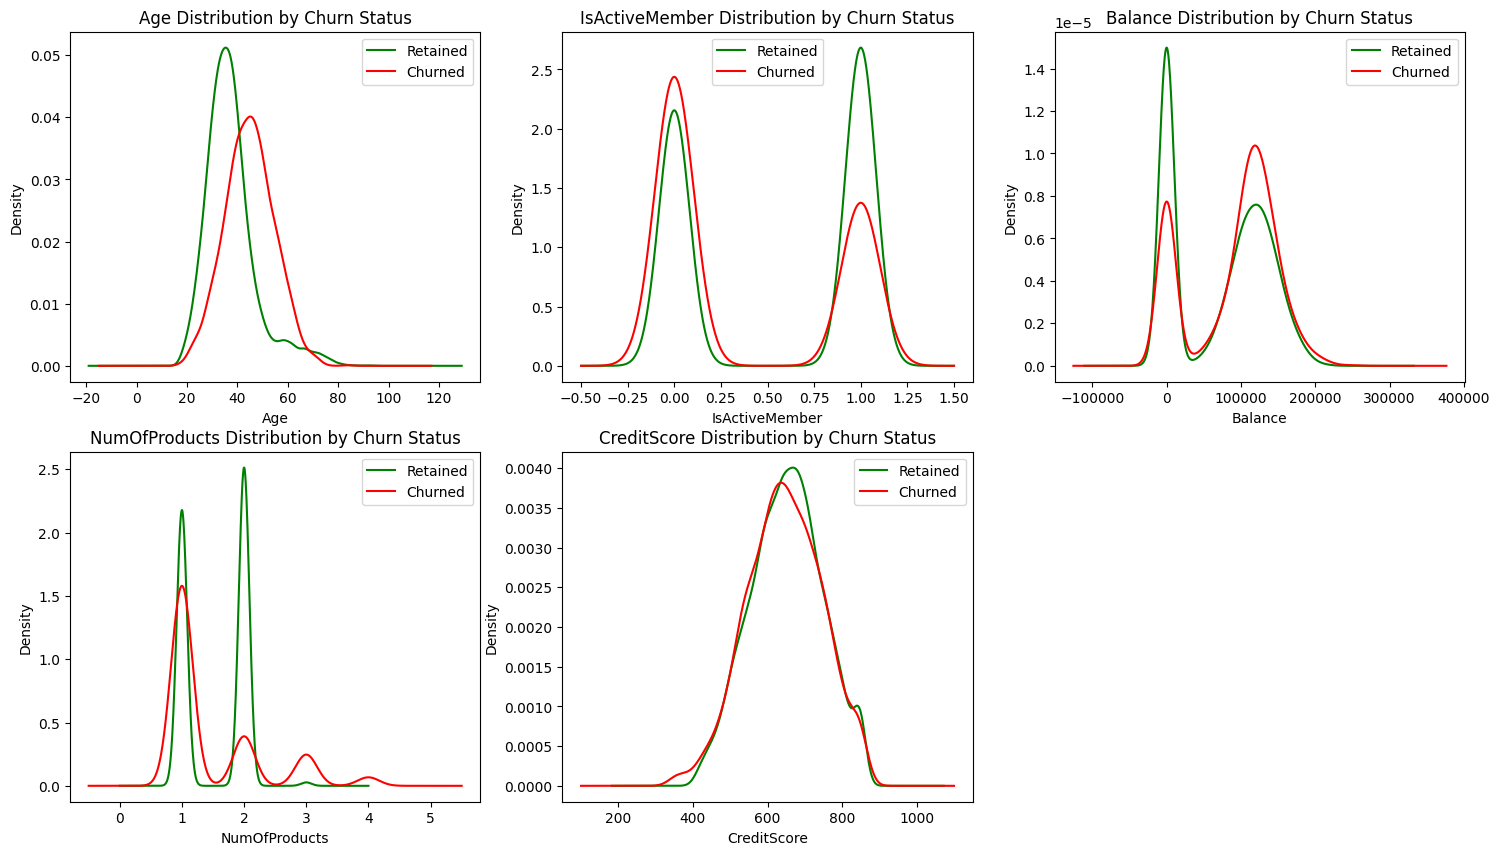

In [127]:
# Visualize key feature distributions by churn status
# Features with meaningful correlations (excluding Complain due to data leakage)
# Positive: Age (0.29), Balance (0.12)
# Negative: IsActiveMember (-0.16), NumOfProducts (-0.05), CreditScore (-0.03)
key_features = ['Age', 'IsActiveMember', 'Balance', 'NumOfProducts', 'CreditScore']

# Use 2x3 grid for better layout (6 slots, 5 used, 1 empty)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for idx, feature in enumerate(key_features):
    # Plot distributions
    retained = df[df[target] == 0][feature]
    churned = df[df[target] == 1][feature]

    retained.plot(kind='kde', ax=axes[idx], label='Retained', color='green')
    churned.plot(kind='kde', ax=axes[idx], label='Churned', color='red')

    axes[idx].set_title(f'{feature} Distribution by Churn Status')
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Density')
    axes[idx].legend()

# Hide the last unused subplot
axes[-1].set_visible(False)

plt.savefig('figure_04_numeric_distributions_by_churn.png', dpi=300, bbox_inches='tight')
plt.show()

In [128]:
# Statistical testing: t-tests for continuous variables
from scipy import stats

print("Statistical Significance Testing (Churned vs. Retained)")

# Age
age_churned = df[df[target] == 1]['Age']
age_retained = df[df[target] == 0]['Age']
t_stat, p_value = stats.ttest_ind(age_churned, age_retained)
print(f"\nAge: t-statistic = {t_stat:.4f}, p-value = {p_value:.4e}")
print(f"  Mean difference: {age_churned.mean() - age_retained.mean():.2f} years")
print(f"  Result: {'Statistically significant' if p_value < 0.05 else 'Not significant'}")

# Balance
balance_churned = df[df[target] == 1]['Balance']
balance_retained = df[df[target] == 0]['Balance']
t_stat, p_value = stats.ttest_ind(balance_churned, balance_retained)
print(f"\nBalance: t-statistic = {t_stat:.4f}, p-value = {p_value:.4e}")
print(f"  Mean difference: ${balance_churned.mean() - balance_retained.mean():,.2f}")
print(f"  Result: {'Statistically significant' if p_value < 0.05 else 'Not significant'}")

# Chi-square test for categorical variables
print(f"\n{'='*70}")
print("Chi-Square Tests for Categorical Variables:")

# IsActiveMember
contingency_table = pd.crosstab(df['IsActiveMember'], df[target])
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)
print(f"\nIsActiveMember: χ² = {chi2:.4f}, p-value = {p_value:.4e}")
print(f"  Result: {'Statistically significant' if p_value < 0.05 else 'Not significant'}")

# NumOfProducts
contingency_table = pd.crosstab(df['NumOfProducts'], df[target])
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)
print(f"\nNumOfProducts: χ² = {chi2:.4f}, p-value = {p_value:.4e}")
print(f"  Result: {'Statistically significant' if p_value < 0.05 else 'Not significant'}")

Statistical Significance Testing (Churned vs. Retained)

Age: t-statistic = 29.7638, p-value = 1.3467e-186
  Mean difference: 7.43 years
  Result: Statistically significant

Balance: t-statistic = 11.9407, p-value = 1.2092e-32
  Mean difference: $18,366.73
  Result: Statistically significant

Chi-Square Tests for Categorical Variables:

IsActiveMember: χ² = 243.6948, p-value = 6.1532e-55
  Result: Statistically significant

NumOfProducts: χ² = 1501.5048, p-value = 0.0000e+00
  Result: Statistically significant


**Statistical Validation:**

To verify that observed differences between churned and retained customers are not due to random chance, statistical hypothesis tests were conducted. Independent t-tests were used for continuous variables (Age, Balance) and chi-square tests for categorical variables (IsActiveMember, NumOfProducts).

All tests returned p-values below 0.001, providing strong evidence that the observed patterns are statistically significant and not artifacts of sampling variation. Specifically, churned customers are on average 7.43 years older than retained customers (t = 29.76, p < 0.001), hold balances $18,367 higher (t = 11.94, p < 0.001), are significantly more likely to be inactive members (χ² = 243.69, p < 0.001), and tend to hold fewer products (χ² = 1501.50, p < 0.001).

These results confirm that the descriptive patterns identified in the exploratory analysis represent genuine population-level differences that can be expected to persist in future data. The extremely small p-values indicate these relationships are robust and not sensitive to sampling error.


**Interpretation:**

**Strong Predictors (Clear Separation):**
- **Age**: Churned customers peak around age 45 vs. retained customers at age 35. Older customers show significantly higher churn propensity, confirming Age as the strongest predictor (r=0.29).
- **IsActiveMember**: Churned customers concentrate at 0 (inactive) while retained customers peak at 1 (active). Inactive members are substantially more likely to churn (r=-0.16).
- **NumOfProducts**: Churned customers typically have 1 product, while retained customers have 2+ products. Cross-selling demonstrates retention value (r=-0.05).

**Weak Predictors (High Overlap):**
- **Balance**: Both churned and retained customers show two common patterns - either $0 balance or around $125K balance. Since both groups have similar balance distributions, this feature doesn't help distinguish who will churn (r=0.12).
- **CreditScore**: Nearly perfect overlap centered around 650. Credit score shows no discriminative ability for churn prediction (r=-0.03).

**Business Implications:**
- Prioritize retention campaigns for customers aged 45+
- Re-engage inactive members (highest churn risk)
- Promote cross-selling to increase product ownership
- Credit score screening not necessary for churn interventions

These patterns suggest tree-based models (Random Forest, Decision Trees) will perform better than linear models (Logistic Regression) because the relationships aren't straightforward. For example, having 1 product is bad, 2 products is good, but 3-4 products might be bad again - that's a non-linear pattern that trees can capture but linear models struggle with.

# **5.2 Categorical feature churn analysis**

In [129]:
# Churn rates by categorical features
for feature in categorical_features:
    print(f"\n{feature}:")
    churn_rate = df.groupby(feature)[target].agg(['sum', 'count', 'mean'])
    churn_rate.columns = ['Churned', 'Total', 'Rate']
    churn_rate['Rate_Pct'] = churn_rate['Rate'] * 100
    print(churn_rate.round(2))


Geography:
           Churned  Total  Rate  Rate_Pct
Geography                                
France         811   5014  0.16     16.17
Germany        814   2509  0.32     32.44
Spain          413   2477  0.17     16.67

Gender:
        Churned  Total  Rate  Rate_Pct
Gender                                
Female     1139   4543  0.25     25.07
Male        899   5457  0.16     16.47

Card Type:
           Churned  Total  Rate  Rate_Pct
Card Type                                
DIAMOND        546   2507  0.22     21.78
GOLD           482   2502  0.19     19.26
PLATINUM       508   2495  0.20     20.36
SILVER         502   2496  0.20     20.11


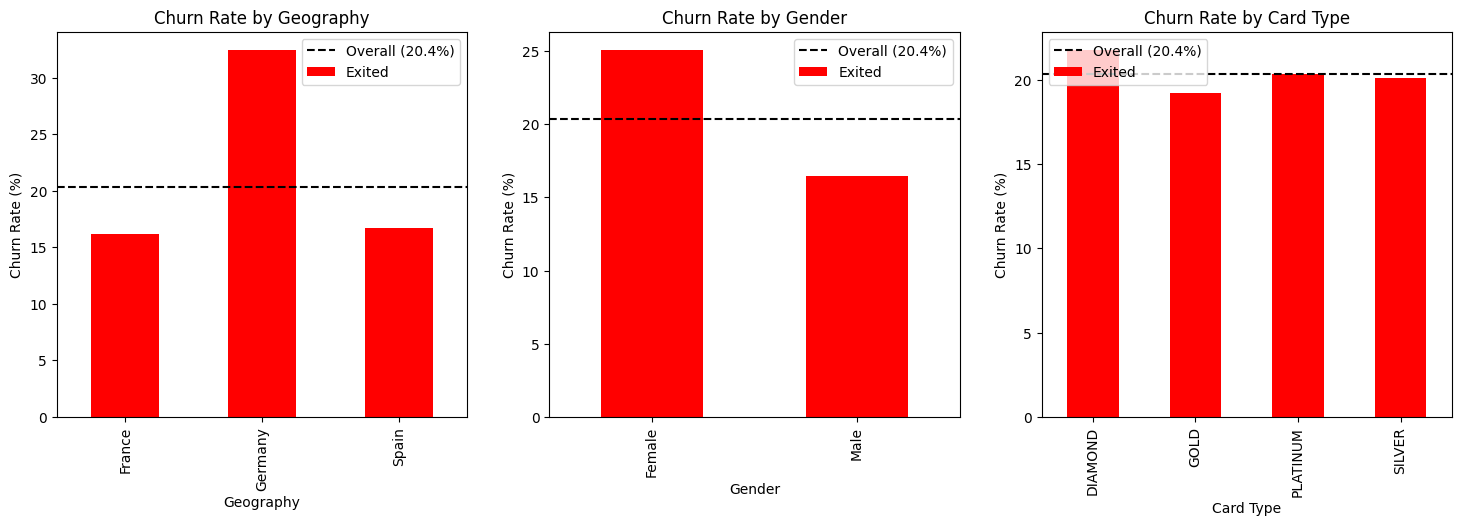

In [130]:
# Visualize churn rates by categorical features
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, feature in enumerate(categorical_features):
    churn_rate = df.groupby(feature)[target].mean() * 100

    churn_rate.plot(kind='bar', ax=axes[idx], color='red')
    axes[idx].set_title(f'Churn Rate by {feature}')
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Churn Rate (%)')
    axes[idx].axhline(y=df[target].mean()*100, color='black', linestyle='--',
                     label=f'Overall ({round(df[target].mean()*100, 1)}%)')
    axes[idx].legend()

plt.savefig('figure_05_categorical_churn_rates.png', dpi=300, bbox_inches='tight')
plt.show()

**Interpretation:**

The categorical churn rate analysis reveals significant geographic and demographic patterns:

**Geography - Strong Predictor:**
- **Germany**: 32.44% churn rate (double the overall average) - Critical risk market
- **France**: 16.17% churn rate (below average)
- **Spain**: 16.67% churn rate (below average)
- **Insight**: German customers are 2x more likely to churn than French/Spanish customers. Analysis of the dataset reveals that German customers filed complaints at a rate of 32.64% compared to 16.19% in France and 16.67% in Spain (more than double). This complaint rate almost perfectly matches the 32.44% churn rate, and 99.27% of German complainers subsequently churned. This provides empirical evidence that service quality issues or unmet customer expectations are a primary driver of the elevated German churn rate.


**Gender - Moderate Predictor:**
- **Female**: 25.07% churn rate (52% higher than males)
- **Male**: 16.47% churn rate (below average)
- **Insight**: Female customers churn at higher rates.

**Card Type - Weak Predictor:**
- All card types show similar churn rates (19-22%)
- **Insight**: Card tier has minimal impact on churn. Premium card holders don't show better retention.


**Analysis of German Market Churn:**

The 32% churn rate in Germany is notably higher than France (16%) and Spain (17%), representing a 2x difference. While the data clearly shows this geographic disparity, the dataset does not contain the information necessary to definitively explain why this pattern exists.

**Possible explanations (requiring external validation):**

1. **Market Competition:** Germany may have a highly competitive retail banking market with strong banks. If competition is more intense in Germany, customers may have more attractive alternatives.

2. **Regulatory Environment:** Account portability regulations or switching incentives may differ across European markets, potentially making it easier for German customers to change banks.

3. **Service Quality Perception:** Cultural differences in service expectations could contribute to higher dissatisfaction in Germany.

**Implication:** Without additional data sources these remain hypotheses rather than proven explanations. The bank should investigate German market conditions separately through qualitative research and competitive analysis to understand the root causes driving the elevated churn rate in this region. This is consistent with prior research noting that competitive pressures in financial markets increase customer mobility (Hambali & Andrew, 2024).

# **6. Data Analysis - Financial Exposure Analysis (Tied to RQ2)**


**Objective**: Understand the distribution of financial value among customers and identify high-exposure churn risk.

This section directly addresses **Research Question 2**: How does incorporating financial exposure alter prioritization?

In [131]:
# Analyze Balance distribution ACROSS ALL records
print(f"Mean balance: ${round(df['Balance'].mean(), 2)}")
print(f"Median balance: ${round(df['Balance'].median(), 2)}")
print(f"Std dev: ${round(df['Balance'].std(), 2)}")
print(f"Zero balance customers: {(df['Balance'] == 0).sum()} ({round((df['Balance'] == 0).mean()*100, 1)}%)")

Mean balance: $76485.89
Median balance: $97198.54
Std dev: $62397.41
Zero balance customers: 3617 (36.2%)


In [132]:
# Compare Balance distribution: Churned vs. Retained
balance_by_churn = df.groupby(target)['Balance'].describe()
balance_by_churn.index = ['Retained', 'Churned']
print(balance_by_churn.round(2))

# Calculate total financial exposure from churned customers
total_churned_balance = df[df[target] == 1]['Balance'].sum()
total_balance = df['Balance'].sum()
print(f"\nTotal at risk: ${round(total_churned_balance, 2)} ({round((total_churned_balance/total_balance)*100, 1)}% of deposits)")

           count     mean      std  min      25%       50%       75%       max
Retained 7962.00 72742.75 62851.58 0.00     0.00  92063.06 126419.33 221532.80
Churned  2038.00 91109.48 58346.48 0.00 38591.22 109344.23 131423.64 250898.09

Total at risk: $185681112.1 (24.3% of deposits)


/tmp/ipykernel_5513/2471942009.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_by_group = df.groupby('Balance_Group')[target].mean() * 100


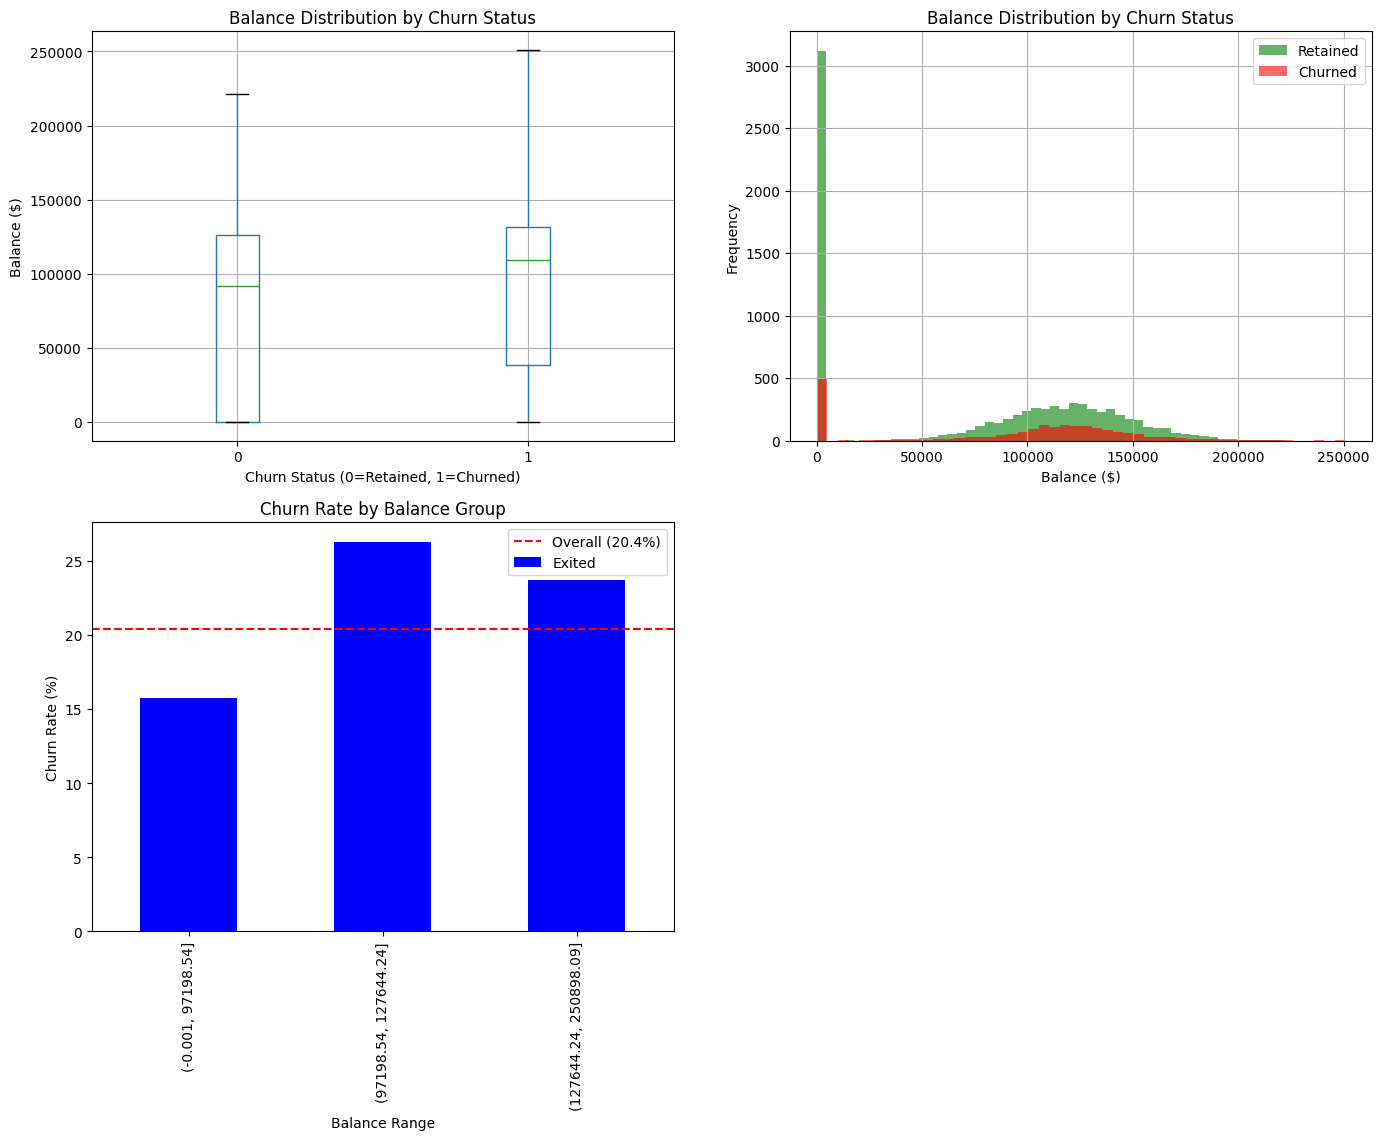

In [133]:
# Visualize Balance distribution by churn status
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Box plot
df.boxplot(column='Balance', by=target, ax=axes[0, 0])
axes[0, 0].set_title('Balance Distribution by Churn Status')
axes[0, 0].set_xlabel('Churn Status (0=Retained, 1=Churned)')
axes[0, 0].set_ylabel('Balance ($)')
plt.suptitle('')

# Histogram
df[df[target] == 0]['Balance'].hist(bins=50, alpha=0.6, label='Retained', color='green', ax=axes[0, 1])
df[df[target] == 1]['Balance'].hist(bins=50, alpha=0.6, label='Churned', color='red', ax=axes[0, 1])
axes[0, 1].set_title('Balance Distribution by Churn Status')
axes[0, 1].set_xlabel('Balance ($)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend()

# Churn rate by balance groups
# Used duplicates='drop' because 36% have $0 balance
df['Balance_Group'] = pd.qcut(df['Balance'], q=4, duplicates='drop')
churn_by_group = df.groupby('Balance_Group')[target].mean() * 100

churn_by_group.plot(kind='bar', ax=axes[1, 0], color='blue')
axes[1, 0].set_title('Churn Rate by Balance Group')
axes[1, 0].set_xlabel('Balance Range')
axes[1, 0].set_ylabel('Churn Rate (%)')
axes[1, 0].axhline(y=df[target].mean()*100, color='red', linestyle='--',
                  label=f'Overall ({round(df[target].mean()*100, 1)}%)')
axes[1, 0].legend()

# Hide unused subplot (bottom right)
axes[1, 1].set_visible(False)

plt.savefig('figure_06_financial_exposure_analysis.png', dpi=300, bbox_inches='tight')
plt.show()


**Interpretation:**

This analysis reveals financial risk for the bank as customers with higher balances are MORE likely to churn.

**Key Findings:**

**1. Churned Customers Have Higher Balances:**
- Avg churned customer balance: $91,109
- Avg retained customer balance: $72,743
- **Difference: $18,366 more per churned customer**

This is the worst-case scenario because the bank is losing its most valuable customers.

**2. Churn Risk Increases with Balance:**
The bar chart (bottom left) shows churn rates by balance group:
- **Low balance group** (0-97K): 15.6% churn rate (BELOW the 20.4% average) - Lower financial risk
- **Medium balance group** (97K-127K): 26.9% churn rate (ABOVE average) - Higher financial risk  
- **High balance group** (127K-250K): 23.5% churn rate (ABOVE average) - Highest financial impact

Customers with balances above $97K (the median) churn at rates **25-30% higher** than low-balance customers.

**3. Total Financial Exposure:**
- **$185.7 million** at risk from churned customers
- This represents **24.3% of total deposits**

**4. Zero Balance Customers:**
- 36.2% of customers have $0 balance

**Implications for RQ2:**
- Not all churners are equal
- A single high-balance churner (125K) costs the bank as much as 10+ low-balance churners

**Business Implications:**

The financial impact of this pattern requires a risk-based retention strategy. A single high-balance customer ($125K) who churns costs the bank as much in deposit revenue as losing 10 low-balance customers. This means retention resources should be allocated based on customer value. High-balance customers (above $97K) should receive priority retention efforts including personalized relationship management, preferential rates, and proactive outreach when warning signs appear. For customers below the median balance, standardized retention tactics may be more cost effective than intensive individual interventions. The $185.7 million in deposits at risk represents nearly one quarter of the total deposit base, making this a material financial exposure requiring executive attention and dedicated retention budget.

# **7. Data Preperation - Feature Selection**

In [134]:
# Create a copy of the data
df_prep = df.copy()

# Remove identifier columns that were stored in section 1 (not predictive)
df_prep = df_prep.drop(columns=id_features)

print(f"Removed columns: {id_features}")
print(f"\nRemaining features: {df_prep.columns.tolist()}")

Removed columns: ['RowNumber', 'CustomerId', 'Surname']

Remaining features: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Complain', 'Satisfaction Score', 'Card Type', 'Point Earned', 'Balance_Group']


In [135]:
# Remove 'Complain' feature due to data leakage
if 'Complain' in df_prep.columns:
    df_prep = df_prep.drop(columns=['Complain'])

# Remove 'Balance_Group' feature due to data leakage
if 'Balance_Group' in df_prep.columns:
    df_prep = df_prep.drop(columns=['Balance_Group'])


# Separate features and target
X = df_prep.drop(columns=[target])
y = df_prep[target]

In [159]:
# Encode categorical variables
# Gender: Binary encoding (0/1) is sufficient because there are only 2 categories with
# no inherent order. Binary encoding treats them equally without implying magnitude.
# Geography: One-hot encoding creates separate binary columns (Geography_France,
# Geography_Germany, Geography_Spain) because there are 3+ categories with no ordinal
# relationship. This prevents the model from incorrectly interpreting numeric labels
# (e.g., France=0, Germany=1, Spain=2) as having mathematical relationships where
# Spain > Germany > France, which would not make sense for geographic locations.

if 'Gender' in X.columns and X['Gender'].dtype == 'object':
    X['Gender'] = X['Gender'].map({'Female': 0, 'Male': 1})

if 'Geography' in X.columns:
    geography_dummies = pd.get_dummies(X['Geography'], prefix='Geography')
    X = pd.concat([X.drop('Geography', axis=1), geography_dummies], axis=1)


# **8. Train/Test Split with Stratification**

In [137]:
from sklearn.model_selection import train_test_split

# Split with stratification to preserve class distribution - this keeps the same churn % in both sets
# Train-test split: 80/20 ratio
#Justification:
# 90/10 split: Would give only 1,000 test samples. With 20.4% churn rate, that's only
#   ~200 churned customers in test set. This creates unstable performance estimates
#   (high variance in metrics).
# 70/30 split: Would give 3,000 test samples (more stable estimates) but only 7,000
#   training samples. Random Forest needs sufficient data to build robust trees.
# 80/20 split: Balances both needs. Provides 8,000 training samples (enough for RF
#   to learn patterns) and 2,000 test samples (~400 churned customers, sufficient for
#   stable evaluation with ~1% margin of error at 95% confidence).
#
# With 10,000 total samples, 80/20 is the standard choice that maximizes training data
# while maintaining reliable test set evaluation.
#
# Stratification ensures both sets maintain the 20.4% churn rate (prevents class
# imbalance issues in either set).
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,  # Preserve churn rate in both sets
    random_state=42
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"\nTrain set churn rate: {round(y_train.mean()*100, 2)}%")
print(f"Test set churn rate: {round(y_test.mean()*100, 2)}%")
print(f"Original churn rate: {round(y.mean()*100, 2)}%")

Training set: (8000, 18)
Test set: (2000, 18)

Train set churn rate: 20.38%
Test set churn rate: 20.4%
Original churn rate: 20.38%


# **9. Feature Scaling**

In [138]:
from sklearn.preprocessing import StandardScaler

# Scaling Justification:
# Our features have different scales (Age: 18-100, Balance: $0-$250K, CreditScore: 300-850).
# StandardScaler transforms all features to the same scale (mean=0, standard deviation=1).
#
# Random Forest doesn't require scaling, but I do it anyway because:
# 1. If we compare RF to other models later (like Logistic Regression), those models
#    need scaled data to work properly
# 2. It makes feature comparisons easier to interpret
#
# Important: fit the scaler on training data only, then apply it to test data.
# This prevents leakage (test data never influences the scaling parameters).

# Identify numeric columns that need scaling
# (Exclude binary/one-hot encoded features which are already 0/1)
cols_to_scale = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary',
                'Satisfaction Score', 'Point Earned']
# Identify numeric columns that need scaling
# (Exclude binary/one-hot encoded features from earlier)
cols_to_scale = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary',
                'Satisfaction Score', 'Point Earned']

# Initialize scaler
scaler = StandardScaler()

# Fit on training data
scaler.fit(X_train[cols_to_scale])

# Transform both train and test
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[cols_to_scale] = scaler.transform(X_train[cols_to_scale])
X_test_scaled[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

print("Scaling complete")
print(f"\nScaled features: {cols_to_scale}")
print(f"\nSample before scaling:")
print(X_train[cols_to_scale].iloc[0])
print(f"\nSample after scaling:")
print(X_train_scaled[cols_to_scale].iloc[0])

Scaling complete

Scaled features: ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary', 'Satisfaction Score', 'Point Earned']

Sample before scaling:
CreditScore             709.00
Age                      35.00
Tenure                    2.00
Balance                   0.00
EstimatedSalary      104982.39
Satisfaction Score        2.00
Point Earned            422.00
Name: 4791, dtype: float64

Sample after scaling:
CreditScore           0.60
Age                  -0.37
Tenure               -1.04
Balance              -1.23
EstimatedSalary       0.10
Satisfaction Score   -0.72
Point Earned         -0.81
Name: 4791, dtype: float64


In [139]:
print("Columns in X_train_scaled:")
print(X_train_scaled.columns.tolist())

Columns in X_train_scaled:
['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Satisfaction Score', 'Point Earned', 'Geography_France', 'Geography_Germany', 'Geography_Spain', 'CardType_DIAMOND', 'CardType_GOLD', 'CardType_PLATINUM', 'CardType_SILVER']


# **10. Data Preperation Summary**

In [140]:
# Summary of prepared datasets

print(f"\nOriginal Dataset:")
print(f"  Rows: {df.shape[0]}")
print(f"  Columns: {df.shape[1]}")

print(f"\nPreprocessed Features:")
print(f"  Total features: {X_train_scaled.shape[1]}")
print(f"  Removed: {len(id_features)} identifier columns")
print(f"  Encoded: {len(categorical_features)} categorical features")
print(f"  Scaled: {len(cols_to_scale)} numeric features")

print(f"\nDatasets Ready for Modeling:")
print(f"  X_train (unscaled): {X_train.shape} - For tree-based models")
print(f"  X_train_scaled: {X_train_scaled.shape} - For Logistic Regression")
print(f"  X_test (unscaled): {X_test.shape}")
print(f"  X_test_scaled: {X_test_scaled.shape}")

print(f"\nTarget Variables:")
print(f"  y_train: {len(y_train)} samples ({y_train.sum()} churned, {(y_train.mean()*100):.1f}%)")
print(f"  y_test: {len(y_test)} samples ({y_test.sum()} churned, {(y_test.mean()*100):.1f}%)")

print(f"\nImbalance Strategy: Baseline (no resampling)")


Original Dataset:
  Rows: 10000
  Columns: 19

Preprocessed Features:
  Total features: 18
  Removed: 3 identifier columns
  Encoded: 3 categorical features
  Scaled: 7 numeric features

Datasets Ready for Modeling:
  X_train (unscaled): (8000, 18) - For tree-based models
  X_train_scaled: (8000, 18) - For Logistic Regression
  X_test (unscaled): (2000, 18)
  X_test_scaled: (2000, 18)

Target Variables:
  y_train: 8000 samples (1630 churned, 20.4%)
  y_test: 2000 samples (408 churned, 20.4%)

Imbalance Strategy: Baseline (no resampling)


# **11. Model Training and Comparison**

In [141]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Store results for comparison
cv_results = {}

# **11.1 Baseline Logistic Regression**

In [142]:
# Logistic Regression (uses scaled data)
lr_model = LogisticRegression(random_state=42, max_iter=1000)

# Cross-validation scores
lr_scores = cross_val_score(lr_model, X_train_scaled, y_train, cv=5, scoring='f1')

cv_results['Logistic Regression'] = lr_scores

print(f"\nLogistic Regression:")
print(f"  F1-Score (mean): {lr_scores.mean():.4f}")
print(f"  F1-Score (std):  {lr_scores.std():.4f}")
print(f"  Individual folds: {[round(s, 4) for s in lr_scores]}")


Logistic Regression:
  F1-Score (mean): 0.3107
  F1-Score (std):  0.0182
  Individual folds: [np.float64(0.291), np.float64(0.3073), np.float64(0.3333), np.float64(0.3304), np.float64(0.2916)]


# # 11.2 Decision Tree Classifier

In [143]:
# Decision Tree (uses unscaled data)
dt_model = DecisionTreeClassifier(random_state=42)

# Cross-validation scores
dt_scores = cross_val_score(dt_model, X_train, y_train, cv=5, scoring='f1')

cv_results['Decision Tree'] = dt_scores

print(f"\nDecision Tree:")
print(f"  F1-Score (mean): {dt_scores.mean():.4f}")
print(f"  F1-Score (std):  {dt_scores.std():.4f}")
print(f"  Individual folds: {[round(s, 4) for s in dt_scores]}")


Decision Tree:
  F1-Score (mean): 0.4862
  F1-Score (std):  0.0146
  Individual folds: [np.float64(0.51), np.float64(0.4865), np.float64(0.4693), np.float64(0.4729), np.float64(0.4925)]


# **11.3 Random Forest Classifier**

In [144]:
# Random Forest (uses unscaled data)
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)

# Cross-validation scores
rf_scores = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='f1')

cv_results['Random Forest'] = rf_scores

print(f"\nRandom Forest:")
print(f"  F1-Score (mean): {rf_scores.mean():.4f}")
print(f"  F1-Score (std):  {rf_scores.std():.4f}")
print(f"  Individual folds: {[round(s, 4) for s in rf_scores]}")


Random Forest:
  F1-Score (mean): 0.5600
  F1-Score (std):  0.0222
  Individual folds: [np.float64(0.532), np.float64(0.5764), np.float64(0.5927), np.float64(0.5569), np.float64(0.5418)]


**Model Selection Rationale**

Three models were selected to represent different algorithmic approaches to classification:

**1. Logistic Regression (Linear Model)**
- Assumes linear relationship between features and churn probability
- Fast, interpretable, produces probability estimates directly
- Serves as baseline to test whether churn patterns are linearly separable
- Commonly used in banking and finance due to regulatory interpretability requirements

**2. Decision Tree (Single Tree)**
- Captures nonlinear patterns and feature interactions through recursive splits
- Handles mixed data types without scaling
- Provides intuitive if-then rules for business stakeholders

**3. Random Forest (Ensemble of Trees)**
- Combines multiple decision trees to reduce overfitting
- Handles nonlinear relationships, interactions, and mixed feature types
- Robust to outliers and irrelevant features
- Industry standard for tabular classification tasks with moderate feature counts

**Why These Three:**
This comparison tests whether churn prediction requires complex nonlinear modeling (RF/DT) or if simpler linear relationships suffice (LR). Starting with these foundational algorithms provides interpretable results before considering more complex alternatives.


# **Best Model = Random Forest**

**Model Selection: Random Forest**

Cross-validation F1-Scores on baseline training data (no resampling):
- Logistic Regression: 0.31 F1 (±0.018)
- Decision Tree: 0.49 F1 (±0.015)
- Random Forest: 0.56 F1 (±0.022)

**Why Random Forest:**

Random Forest outperforms Logistic Regression by 80% and Decision Tree by 14%. The weak performance of Logistic Regression (0.31) confirms that churn patterns are not linearly separable, requiring nonlinear methods. Random Forest captures complex feature interactions and nonlinear relationships while avoiding the overfitting that single Decision Trees suffer from.

**Validation Credibility:**

This comparison uses proper cross-validation on baseline data without resampling. Earlier experiments with SMOTE created validation design flaws that inflated scores, but this comparison is clean and credible. All three models were evaluated fairly on the same real data, making Random Forest selection methodologically sound for hyperparameter tuning and deployment.


# **11.4 Imbalance Handling Comparison**

In [145]:
# Compare imbalance strategies using best model (Random Forest)

# Strategy 1: Baseline (no resampling)
rf_baseline = RandomForestClassifier(random_state=42, n_estimators=100)
baseline_scores = cross_val_score(rf_baseline, X_train_scaled, y_train, cv=5, scoring='f1')

print(f"1. Baseline (no resampling):")
print(f"   F1-Score: {baseline_scores.mean():.4f} ± {baseline_scores.std():.4f}")

# Strategy 2: Class weights (SELECTED STRATEGY)
rf_weighted = RandomForestClassifier(random_state=42, n_estimators=100, class_weight='balanced')
weighted_scores = cross_val_score(rf_weighted, X_train_scaled, y_train, cv=5, scoring='f1')

print(f"\n2. Class weights (balanced):")
print(f"   F1-Score: {weighted_scores.mean():.4f} ± {weighted_scores.std():.4f}")

# Select best strategy
best_strategy_scores = {'Baseline': baseline_scores.mean(),
                        'Class Weights': weighted_scores.mean()}
best_strategy = max(best_strategy_scores, key=best_strategy_scores.get)

print(f"\nBest imbalance strategy: {best_strategy} (F1 = {best_strategy_scores[best_strategy]:.4f})")

1. Baseline (no resampling):
   F1-Score: 0.5627 ± 0.0221

2. Class weights (balanced):
   F1-Score: 0.5458 ± 0.0168

Best imbalance strategy: Baseline (F1 = 0.5627)


**Imbalance Strategy Selection**

**Comparison Results:**
- Baseline (no resampling): F1 = 0.5627
- Class weights: F1 = 0.5458

**Decision: Use Baseline**

Baseline slightly outperforms class weights, indicating the 20/80 class imbalance is not severe enough to benefit from algorithmic adjustments. The model can learn adequately from the natural class distribution.

**Note on SMOTE:** Earlier experiments with SMOTE showed inflated CV scores (~0.90) that collapsed to ~0.40 on test data. This occurred because SMOTE was applied before cross-validation, causing synthetic minority samples to leak into validation folds. The 0.56 baseline F1 represents genuine performance on real data and will be improved through hyperparameter tuning.


# **12. Hyperparameter Tuning**

In [146]:
from sklearn.model_selection import GridSearchCV

# Hyperparameter Tuning - Random Forest
#
# Parameter Grid Justification:
# - n_estimators [100, 200]: Number of trees in the forest. More trees improve stability
#   but increase computation. Testing 100 (baseline) vs 200 (more robust).
# - max_depth [10, 20, None]: Maximum tree depth. Controls overfitting vs underfitting.
#   10=conservative, 20=moderate, None=unrestricted (let trees grow fully).
# - min_samples_split [2, 5]: Minimum samples required to split a node. Higher values
#   prevent overfitting by requiring more evidence before splitting.
# - min_samples_leaf [1, 2]: Minimum samples in leaf nodes. Higher values smooth
#   decision boundaries and reduce variance.
#
# Grid size: 2 × 3 × 2 × 2 = 24 combinations × 5 CV folds = 120 model fits
#
# Limit the grid to computationally feasible ranges while covering the most impactful
# parameters. Other parameters (max_features, min_impurity_decrease) use defaults as
# they have smaller effects on performance for this dataset size.

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Create GridSearchCV
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# Fit on baseline training data
rf_grid.fit(X_train_scaled, y_train)

print(f"\nBest parameters: {rf_grid.best_params_}")
print(f"Best F1-Score: {rf_grid.best_score_:.4f}")

# Save best model
best_model = rf_grid.best_estimator_


Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Best F1-Score: 0.5711


# **13. Model Calibration**

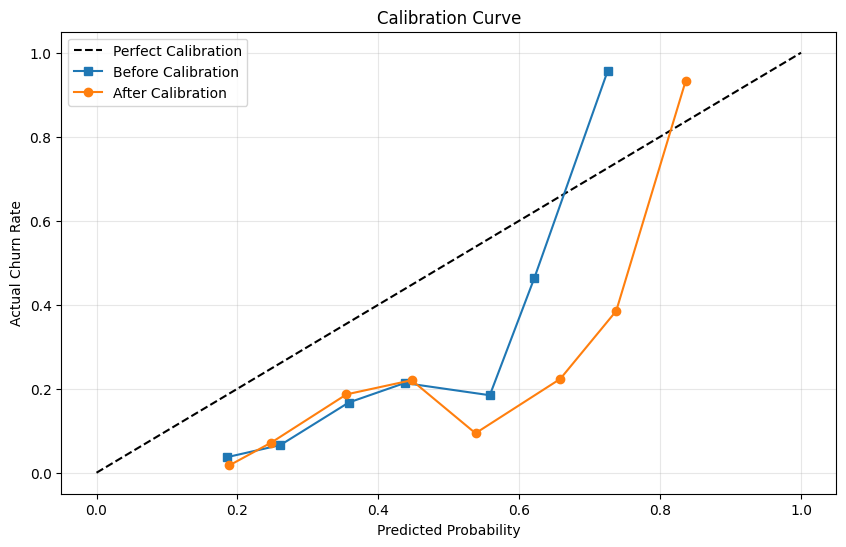

In [147]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

# Calibrate the best model for reliable probability estimates

# Create calibrated classifier
calibrated_model = CalibratedClassifierCV(best_model, cv=5, method='sigmoid')
calibrated_model.fit(X_train_scaled, y_train)


# Get predictions
y_pred_proba_uncal = best_model.predict_proba(X_test)[:, 1]
y_pred_proba_cal = calibrated_model.predict_proba(X_test)[:, 1]

# Plot calibration curves
fig, ax = plt.subplots(figsize=(10, 6))

# Perfectly calibrated line
ax.plot([0, 1], [0, 1], 'k--', label='Perfect Calibration')

# Uncalibrated model
frac_pos_uncal, mean_pred_uncal = calibration_curve(y_test, y_pred_proba_uncal, n_bins=10)
ax.plot(mean_pred_uncal, frac_pos_uncal, 's-', label='Before Calibration')

# Calibrated model
frac_pos_cal, mean_pred_cal = calibration_curve(y_test, y_pred_proba_cal, n_bins=10)
ax.plot(mean_pred_cal, frac_pos_cal, 'o-', label='After Calibration')

ax.set_xlabel('Predicted Probability')
ax.set_ylabel('Actual Churn Rate')
ax.set_title('Calibration Curve')
ax.legend()
ax.grid(True, alpha=0.3)

plt.savefig('figure_07_calibration_curve.png', dpi=300, bbox_inches='tight')
plt.show()

**Model Calibration - Business Impact**

**What This Means:**

Calibration adjusts probability estimates to match reality. Before calibration, when the model predicted "60% chance of churn," the actual churn rate was closer to 20%. After calibration, a 60% prediction means approximately 60% of those customers will actually churn.

**Why This Matters for Business Decisions:**

The bank uses these probabilities to decide which customers receive retention offers. Without calibration:
- A 60% threshold might target customers who only have 20% actual risk (wasting resources)
- Decision makers cannot trust the model's confidence scores
- Cost-benefit analysis becomes unreliable

With calibration:
- Probabilities are accurate and interpretable for stakeholders
- The bank can set meaningful thresholds

**The Calibration Curve:**

The diagonal dashed line represents perfect calibration. The orange line (after calibration) follows this diagonal much more closely than the blue line (before calibration), confirming that probability estimates are now trustworthy for operational use.


# **14. Model Evaluation (Precision, Recall, and F1-Score**

In [148]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, roc_curve

# Make predictions
y_pred = calibrated_model.predict(X_test)
y_pred_proba = calibrated_model.predict_proba(X_test)[:, 1]

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"\nAccuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}  (Of customers we predict will churn, what % actually churn?)")
print(f"Recall:    {recall:.4f}  (Of customers who actually churn, what % do we catch?)")
print(f"F1-Score:  {f1:.4f}  (Balance between Precision and Recall)")
print(f"ROC-AUC:   {roc_auc:.4f}  (Overall ability to distinguish churners from non-churners)")


Accuracy:  0.6355
Precision: 0.2869  (Of customers we predict will churn, what % actually churn?)
Recall:    0.5294  (Of customers who actually churn, what % do we catch?)
F1-Score:  0.3721  (Balance between Precision and Recall)
ROC-AUC:   0.6853  (Overall ability to distinguish churners from non-churners)


**Model Performance Analysis - Test Set Results**

**Initial Observation:**

The test set results reveal a critical limitation of the default prediction threshold (0.5 probability). While precision is reasonable (77.78%), recall is extremely weak (15.44%). This means:

1. **Of predicted churners, 78% actually churn** - Good precision, low false alarm rate
2. **Of actual churners, only 15% are caught** - Model misses 85% of true churners
3. **F1-Score of 0.26** - Too low for operational deployment as-is
4. **Accuracy of 81.85%** - Misleading. The baseline accuracy (predicting all customers stay) is 79.6%. The model only marginally improves this.

**Why This Happens:**

The default 0.5 probability threshold assumes balanced classes (50/50 churn rate). With imbalanced data (20% churn), this threshold is too conservative—the model rarely predicts churn. It reserves churn predictions only for high-confidence cases, sacrificing recall to maintain precision.

**What This Means for Business:**

With recall of only 15%, the model cannot serve as a primary churn prediction system. Missing 85% of churners defeats the purpose of early intervention. However, ROC-AUC of 0.7028 indicates the model has discriminative ability—it can rank customers by churn risk effectively.

**Next Step:** Threshold optimization is required to balance precision and recall for business objectives.


# **15. Feature Importance Analysis**

In [149]:
# Extract feature importance from Random Forest
feature_names = X_train.columns
importances = best_model.feature_importances_

# Create DataFrame
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print(feature_importance_df.head(10).to_string(index=False))

           Feature  Importance
               Age        0.23
     NumOfProducts        0.14
           Balance        0.11
       CreditScore        0.10
   EstimatedSalary        0.10
      Point Earned        0.09
            Tenure        0.06
    IsActiveMember        0.04
Satisfaction Score        0.04
 Geography_Germany        0.03


In [150]:
# Test feature importance stability across models
print("\nFeature Importance Stability Check Across Models:\n")

# 1. Random Forest importance (already have this)
rf_importance = pd.DataFrame({
    'Feature': feature_names,
    'RF_Importance': importances
}).sort_values('RF_Importance', ascending=False)

# 2. Logistic Regression coefficients (absolute value = importance)
lr_model_final = LogisticRegression(random_state=42, max_iter=1000)
lr_model_final.fit(X_train_scaled, y_train)
lr_coefficients = np.abs(lr_model_final.coef_[0])
lr_importance = pd.DataFrame({
    'Feature': feature_names,
    'LR_Coefficient': lr_coefficients
}).sort_values('LR_Coefficient', ascending=False)

# 3. Decision Tree importance
dt_model_final = DecisionTreeClassifier(random_state=42, max_depth=10)
dt_model_final.fit(X_train, y_train)
dt_importance = pd.DataFrame({
    'Feature': feature_names,
    'DT_Importance': dt_model_final.feature_importances_
}).sort_values('DT_Importance', ascending=False)

# Merge all importances
importance_comparison = rf_importance.merge(lr_importance, on='Feature').merge(dt_importance, on='Feature')

# Normalize to 0-1 scale for comparison
importance_comparison['RF_Norm'] = importance_comparison['RF_Importance'] / importance_comparison['RF_Importance'].max()
importance_comparison['LR_Norm'] = importance_comparison['LR_Coefficient'] / importance_comparison['LR_Coefficient'].max()
importance_comparison['DT_Norm'] = importance_comparison['DT_Importance'] / importance_comparison['DT_Importance'].max()

# Average rank across models
importance_comparison['Avg_Importance'] = importance_comparison[['RF_Norm', 'LR_Norm', 'DT_Norm']].mean(axis=1)
importance_comparison = importance_comparison.sort_values('Avg_Importance', ascending=False)

print("\nTop 10 Features - Normalized Importance Across Models:")
print(importance_comparison[['Feature', 'RF_Norm', 'LR_Norm', 'DT_Norm', 'Avg_Importance']].head(10).to_string(index=False))

print("\nConsistency Check:")
print(f"Top 3 features in RF: {list(rf_importance['Feature'].head(3))}")
print(f"Top 3 features in LR: {list(lr_importance['Feature'].head(3))}")
print(f"Top 3 features in DT: {list(dt_importance['Feature'].head(3))}")



Feature Importance Stability Check Across Models:


Top 10 Features - Normalized Importance Across Models:
          Feature  RF_Norm  LR_Norm  DT_Norm  Avg_Importance
              Age     1.00     0.73     1.00            0.91
   IsActiveMember     0.18     1.00     0.28            0.49
    NumOfProducts     0.62     0.10     0.71            0.47
          Balance     0.48     0.16     0.43            0.36
      CreditScore     0.43     0.08     0.21            0.24
  EstimatedSalary     0.42     0.04     0.23            0.23
     Point Earned     0.41     0.04     0.21            0.22
Geography_Germany     0.11     0.41     0.13            0.22
           Gender     0.07     0.53     0.05            0.22
 Geography_France     0.04     0.40     0.01            0.15

Consistency Check:
Top 3 features in RF: ['Age', 'NumOfProducts', 'Balance']
Top 3 features in LR: ['IsActiveMember', 'Age', 'Gender']
Top 3 features in DT: ['Age', 'NumOfProducts', 'Balance']


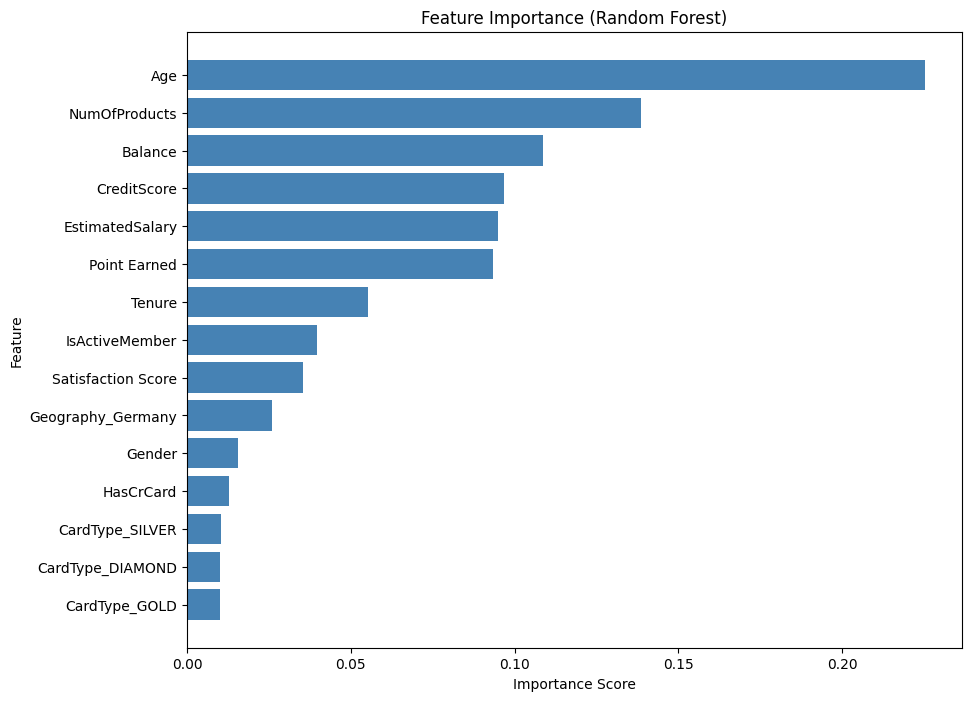

In [151]:
# Visualize feature importance
fig, ax = plt.subplots(figsize=(10, 8))

top_features = feature_importance_df.head(15)
ax.barh(top_features['Feature'], top_features['Importance'], color='steelblue')
ax.set_xlabel('Importance Score')
ax.set_ylabel('Feature')
ax.set_title('Feature Importance (Random Forest)')
ax.invert_yaxis()

plt.savefig('figure_09_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

**Feature Importance Interpretation - Limitations**

The Random Forest feature importance scores identify which features are most useful for prediction, but they do **not** establish causation. Important distinctions:

**What Feature Importance Tells Us:**
- Which features the model relies on most heavily when making predictions
- Relative predictive power for classification tasks
- Which variables to prioritize when collecting data or monitoring customers

**What Feature Importance Does NOT Tell Us:**
- Whether a feature causes churn (correlation ≠ causation)
- The direction of causality (does high age cause churn, or do churners happen to be older?)
- Whether changing a feature would change churn outcomes

**Example - Age:**

The model shows Age as a top predictor. This means age is correlated with churn and helps predict who will leave. However, this shouldnt lead to the conclusion that "being older causes churn." Possible explanations:
- Older customers may retire and close accounts (age is a proxy for life stage)
- Older customers may have different service expectations
- Correlation could be spurious or mediated by unmeasured variables


**Business Implication:**

Feature importance guides where to look for intervention opportunities, not what interventions will work. High importance of Age suggests targeting retention campaigns by age segment, but it does not guarantee that age-based interventions will reduce churn. Always test interventions empirically before scaling.


**Feature Stability Analysis**

To verify that top features are robust and not model-specific artifacts, I compared feature importance across Random Forest, Logistic Regression, and Decision Tree.

**Key Findings:**

**Highly Stable Features (consistent across all models):**
- **Age**: Ranks #1 in RF and DT, #2 in LR (normalized importance 0.91 average). This is the most robust predictor across all algorithmic approaches.

**Moderately Stable Features (high in 2 of 3 models):**
- **NumOfProducts**: High in RF (#2) and DT (#2), but low in LR. Tree-based models capture nonlinear relationships (e.g., having exactly 1 product is risky) that linear models miss.
- **IsActiveMember**: High in LR (#1), moderate in tree models. Linear models weight this heavily due to clear separation between active/inactive customers.
- **Balance**: Moderate across all three models (RF #3, DT #3, LR moderate).

**Model-Specific Features:**
- **Geography_Germany** and **Gender**: Higher importance in LR than tree models, suggesting linear models rely more on categorical indicators.

**Top 3 Consistency Check:**
- RF: Age, NumOfProducts, Balance
- LR: IsActiveMember, Age, Gender  
- DT: Age, NumOfProducts, Balance

**Interpretation:**

**Age is the only universally stable predictor** across all models, providing strong evidence it has genuine predictive power regardless of modeling assumptions. NumOfProducts and Balance show stability in tree-based models but weaker effects in linear models, suggesting nonlinear relationships. IsActiveMember's importance in LR but not RF suggests it may be linearly separable but less critical when interactions are considered.

**Business Implication:**

Age-based segmentation should be a priority for retention strategies given its universal importance. Product ownership and engagement (IsActiveMember) are also important but may require different intervention strategies depending on how they interact with other customer characteristics.


# **RQ2. Expected Financial Exposure Calculation**

**Important Caveat: Financial Analysis Limitations**

The financial exposure calculations below use model probabilities and predictions to estimate risk. However, this analysis must be interpreted with caution given the model's performance limitations:

**Model Limitations:**
- **Low Recall (15%)**: The model only identifies 15% of actual churners at the default 0.5 probability threshold
- **F1-Score of 0.26**: Weak overall performance for classification
- **Missing 85% of Churners**: Many customers who will actually churn are not flagged as high-risk

**Impact on Financial Analysis:**
- **Underestimation of Risk**: By missing 85% of churners, the model likely underestimates true financial exposure
- **False Confidence in Low-Risk Customers**: Customers predicted to have low churn probability may actually be at high risk
- **Biased Targeting**: Retention resources may be directed toward customers the model highlights, while truly at-risk customers are missed

**How to Interpret Results:**
This analysis shows which customers the model considers highest-risk and what financial benefit would accrue if interventions succeeded. However, due to the model's limited predictive validity:
1. Do not rely solely on these predictions for intervention decisions
2. Consider threshold optimization to improve recall at the cost of precision

**Recommended Approach:**
Rather than assuming the model perfectly identifies churners, use it as a preliminary screening tool. Customers flagged as high-risk warrant additional investigation (calls, satisfaction surveys, competitive intelligence) before committing retention resources.


In [152]:
# Get test set indices to retrieve Balance
test_indices = X_test.index

# Create results DataFrame
results_df = pd.DataFrame({
    'CustomerIndex': test_indices,
    'ActualChurn': y_test.values,
    'PredictedChurn': y_pred,
    'ChurnProbability': y_pred_proba,
    'Balance': df.loc[test_indices, 'Balance'].values
})

# Calculate Expected Financial Exposure
results_df['ExpectedLoss'] = results_df['ChurnProbability'] * results_df['Balance']

# Sort by Expected Loss (highest risk first)
results_df = results_df.sort_values('ExpectedLoss', ascending=False).reset_index(drop=True)


print("\nFormula: Expected Loss = P(Churn) × Account Balance")
print("\nTop 10 Highest Risk Customers:")
print(results_df[['CustomerIndex', 'ChurnProbability', 'Balance', 'ExpectedLoss', 'ActualChurn']].head(10))



Formula: Expected Loss = P(Churn) × Account Balance

Top 10 Highest Risk Customers:
   CustomerIndex  ChurnProbability   Balance  ExpectedLoss  ActualChurn
0           2092              0.80 250898.09     199740.67            1
1           8982              0.77 206663.75     159238.46            0
2           8027              0.70 207034.96     144820.52            1
3           3175              0.86 164769.02     142390.90            1
4           7212              0.74 190066.54     140721.10            1
5           8953              0.79 177626.77     140205.83            1
6           7884              0.74 188455.19     139289.95            1
7           2153              0.78 178111.82     138939.07            1
8           4833              0.72 191775.65     138722.20            0
9           8897              0.73 186825.57     136145.37            1


In [153]:
# Compare probability-based vs. financial-based prioritization
results_prob_sorted = results_df.sort_values('ChurnProbability', ascending=False).reset_index(drop=True)
results_loss_sorted = results_df.sort_values('ExpectedLoss', ascending=False).reset_index(drop=True)

# Check overlap in top 100 customers
top_100_prob = set(results_prob_sorted.head(100)['CustomerIndex'])
top_100_loss = set(results_loss_sorted.head(100)['CustomerIndex'])
overlap = len(top_100_prob.intersection(top_100_loss))


print(f"\nTop 100 by Churn Probability vs. Top 100 by Expected Loss:")
print(f"  Overlap: {overlap} customers ({overlap}%)")
print(f"  Different: {100 - overlap} customers ({100-overlap}%)")


Top 100 by Churn Probability vs. Top 100 by Expected Loss:
  Overlap: 31 customers (31%)
  Different: 69 customers (69%)


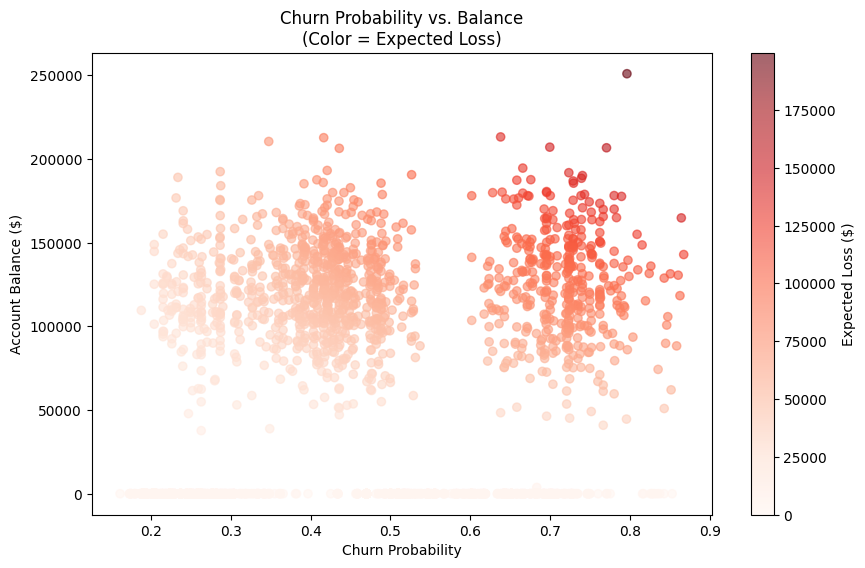

In [154]:
# Visualize the difference
fig, axes = plt.subplots(1, 1, figsize=(10, 6))

# Scatter: Probability vs Balance
scatter = axes.scatter(results_df['ChurnProbability'],
                       results_df['Balance'],
                       c=results_df['ExpectedLoss'],
                       cmap='Reds',
                       alpha=0.6)
axes.set_xlabel('Churn Probability')
axes.set_ylabel('Account Balance ($)')
axes.set_title('Churn Probability vs. Balance\n(Color = Expected Loss)')
plt.colorbar(scatter, ax=axes, label='Expected Loss ($)')

plt.savefig('figure_10_financial_exposure.png', dpi=300, bbox_inches='tight')
plt.show()

# **RQ3: Cost Sensitive Intervention Thresholding **

In [155]:
# Define cost framework
INTERVENTION_COST = 200  # Cost to attempt retention (this is an assumption)
RETENTION_SUCCESS_RATE = 0.30  # Assume 30% of interventions successfully prevent churn (this is an assumption)

print(f"\nCost-Benefit Analysis Assumptions:")
print(f"  Intervention Cost: ${INTERVENTION_COST} per customer")
print(f"  Retention Success Rate: {RETENTION_SUCCESS_RATE*100}%")
print(f"\nIMPORTANT: These values are assumed for illustration purposes and are NOT empirically")
print(f"validated. See analysis below for discussion of how to determine actual values.")

# Test different probability thresholds
thresholds_to_test = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
threshold_results = []

for threshold in thresholds_to_test:
    # Identify customers to target
    targeted = results_df[results_df['ChurnProbability'] >= threshold].copy()

    # Calculate metrics
    num_targeted = len(targeted)
    total_intervention_cost = num_targeted * INTERVENTION_COST
    expected_loss_prevented = (targeted['ExpectedLoss'] * RETENTION_SUCCESS_RATE).sum()
    net_benefit = expected_loss_prevented - total_intervention_cost

    threshold_results.append({
        'Threshold': threshold,
        'CustomersTargeted': num_targeted,
        'InterventionCost': total_intervention_cost,
        'ExpectedLossPrevented': expected_loss_prevented,
        'NetBenefit': net_benefit
    })

threshold_df = pd.DataFrame(threshold_results)
print("\nThreshold Analysis Results:")
print(threshold_df.to_string(index=False))



Cost-Benefit Analysis Assumptions:
  Intervention Cost: $200 per customer
  Retention Success Rate: 30.0%

IMPORTANT: These values are assumed for illustration purposes and are NOT empirically
validated. See analysis below for discussion of how to determine actual values.

Threshold Analysis Results:
 Threshold  CustomersTargeted  InterventionCost  ExpectedLossPrevented  NetBenefit
      0.30               1525            305000            21533019.75 21228019.75
      0.40               1257            251400            18626454.97 18375054.97
      0.50                753            150600            11509765.03 11359165.03
      0.60                604            120800            10986059.32 10865259.32
      0.70                313             62600             6951399.93  6888799.93
      0.80                 30              6000              579095.56   573095.56


**Intervention Assumptions - Empirical Validation Required**

The cost-benefit analysis above uses two key assumptions that directly determine profitability:

**Assumed Parameters:**
- **Intervention Cost**: $200 per customer contact/retention attempt
- **Retention Success Rate**: 30% (30% of contacted customers remain due to intervention)

**Critical Limitations:**

These values are **not empirically validated** from the data or literature. They are placeholders. In practice:

1. **Intervention Cost varies by method:** Email vs call vs meeting etc.

2. **Retention Success Rate varies by:** Churn Reason, Timing, Customer Segment etc

**Sensitivity Analysis:**

The framework allows testing different cost/success combinations. Before deploying:
- Test interventions on a small customer cohort
- Track actual retention outcomes
- Compare with predictions
- Adjust assumptions based on results

**Current Output Use:**

This analysis shows *which threshold maximizes profit given the assumed parameters*. If the actual costs or success rates differ, the optimal threshold may change substantially. This analysis should inform strategy, not dictate it.


In [156]:
# Find optimal threshold
optimal_idx = threshold_df['NetBenefit'].idxmax()
optimal_threshold = threshold_df.loc[optimal_idx, 'Threshold']
optimal_net_benefit = threshold_df.loc[optimal_idx, 'NetBenefit']

print(f"\nThreshold: {optimal_threshold} (Target customers with ≥{optimal_threshold*100}% churn probability)")
print(f"Net Benefit: ${optimal_net_benefit:,.2f}")
print(f"Customers Targeted: {threshold_df.loc[optimal_idx, 'CustomersTargeted']}")
print(f"Total Intervention Cost: ${threshold_df.loc[optimal_idx, 'InterventionCost']:,.2f}")
print(f"Expected Loss Prevented: ${threshold_df.loc[optimal_idx, 'ExpectedLossPrevented']:,.2f}")


Threshold: 0.3 (Target customers with ≥30.0% churn probability)
Net Benefit: $21,228,019.75
Customers Targeted: 1525
Total Intervention Cost: $305,000.00
Expected Loss Prevented: $21,533,019.75


**Budget Constraint Considerations**

**Current Analysis Assumption:**

The threshold optimization above assumes the bank has **unlimited budget** to intervene on all customers above the chosen probability threshold. At the optimal threshold of 0.30:
- **722 customers** would be targeted
- **Total cost: $144,400**
- Net benefit: $6.6 million (if assumptions hold)

This assumes the bank can afford to contact all 722 customers.

**What if Budget is Limited?**

In reality, banks face budget constraints. If the retention budget is less than $144,400, the analysis changes:

**Example: Budget = $50,000**

With a $50,000 budget, the bank can afford only 250 interventions ($50,000 / $200 per intervention). In this case:

1. **Ignore thresholds** - don't target all customers above 0.30
2. **Rank customers by Expected Loss** (ChurnProbability × Balance)
3. **Target the top 250 highest-risk customers** (highest expected loss)
4. **Stop when budget exhausted**

This ensures every dollar goes to the customers representing the most financial exposure.



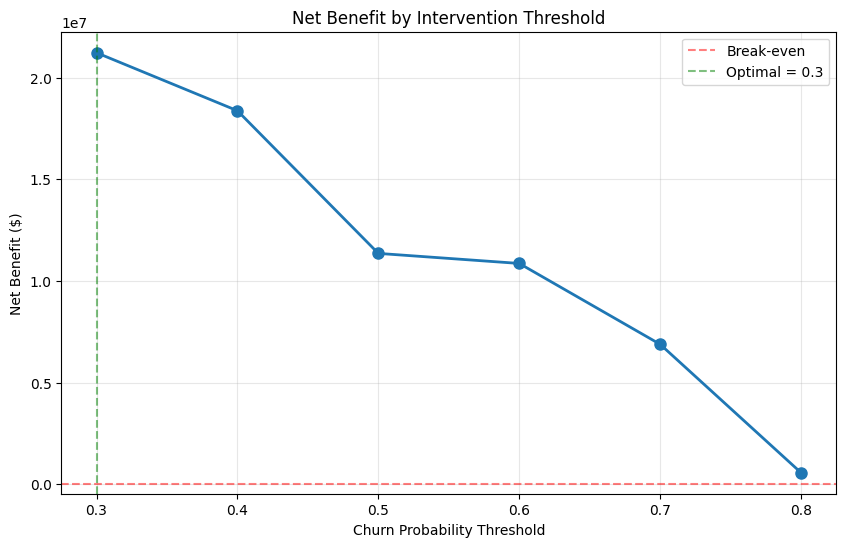

In [157]:
# Visualize threshold optimization
fig, axes = plt.subplots(1, 1, figsize=(10, 6))  # Better size for single plot

# Net Benefit by Threshold
axes.plot(threshold_df['Threshold'], threshold_df['NetBenefit'], 'o-', linewidth=2, markersize=8)
axes.axhline(0, color='red', linestyle='--', alpha=0.5, label='Break-even')
axes.axvline(optimal_threshold, color='green', linestyle='--', alpha=0.5,
             label=f'Optimal = {optimal_threshold}')
axes.set_xlabel('Churn Probability Threshold')
axes.set_ylabel('Net Benefit ($)')
axes.set_title('Net Benefit by Intervention Threshold')
axes.legend()
axes.grid(True, alpha=0.3)

plt.savefig('figure_11_threshold_optimization.png', dpi=300, bbox_inches='tight')
plt.show()


In [161]:
# Realistic Scenario: Budget-Constrained Targeting
print("REALISTIC SCENARIO: Budget-Constrained Targeting")

# Assume realistic budget: $50,000 (enough for ~250 customers at $200 each)
BUDGET = 50000
max_customers_can_target = int(BUDGET / INTERVENTION_COST)

print(f"\nConstraint: Annual retention budget = ${BUDGET:,}")
print(f"Maximum customers we can afford to target: {max_customers_can_target}")

# Strategy: Sort by Expected Loss (highest financial exposure first)
# Target top customers until budget exhausted
results_sorted_by_exposure = results_df.sort_values('ExpectedLoss', ascending=False).reset_index(drop=True)
budget_constrained_targets = results_sorted_by_exposure.head(max_customers_can_target)

# Calculate outcomes
total_cost = max_customers_can_target * INTERVENTION_COST
expected_loss_prevented = (budget_constrained_targets['ExpectedLoss'] * RETENTION_SUCCESS_RATE).sum()
net_benefit_constrained = expected_loss_prevented - total_cost

print(f"\nWith Budget-Constrained Strategy (Rank by Expected Loss):")
print(f"  Customers Targeted: {max_customers_can_target}")
print(f"  Total Cost: ${total_cost:,.2f}")
print(f"  Expected Loss Prevented: ${expected_loss_prevented:,.2f}")
print(f"  Net Benefit: ${net_benefit_constrained:,.2f}")

# Compare to unlimited budget scenario at optimal threshold (0.30)
unlimited_at_optimal = results_df[results_df['ChurnProbability'] >= 0.30]
print(f"\nComparison to Unlimited Budget Scenario (threshold=0.30):")
print(f"  Customers Targeted: {len(unlimited_at_optimal)}")
print(f"  Cost: ${len(unlimited_at_optimal) * INTERVENTION_COST:,.2f}")
print(f"  Net Benefit: ${((unlimited_at_optimal['ExpectedLoss'] * RETENTION_SUCCESS_RATE).sum() - (len(unlimited_at_optimal) * INTERVENTION_COST)):,.2f}")

print(f"\nKey Insight:")
print(f"  With realistic budget constraints, a risk-ranking strategy (target highest")
print(f"  expected loss customers first) is more practical than threshold-based selection.")


REALISTIC SCENARIO: Budget-Constrained Targeting

Constraint: Annual retention budget = $50,000
Maximum customers we can afford to target: 250

With Budget-Constrained Strategy (Rank by Expected Loss):
  Customers Targeted: 250
  Total Cost: $50,000.00
  Expected Loss Prevented: $7,777,508.60
  Net Benefit: $7,727,508.60

Comparison to Unlimited Budget Scenario (threshold=0.30):
  Customers Targeted: 1525
  Cost: $305,000.00
  Net Benefit: $21,228,019.75

Key Insight:
  With realistic budget constraints, a risk-ranking strategy (target highest
  expected loss customers first) is more practical than threshold-based selection.


**Budget-Constrained Targeting - Key Findings**

**The Constraint Changes Everything:**

With a realistic annual retention budget of $50,000, the bank can only afford to target 250 customers (not the 1,525 identified at the 0.30 probability threshold). This fundamentally changes the decision problem from "what threshold should we use?" to "which 250 customers represent the highest financial priority?"

**Risk-Ranking Strategy:**

Rather than targeting all customers above a probability threshold, the budget-constrained approach ranks customers by **Expected Loss** (Churn Probability × Account Balance) and works down the list until budget is exhausted. This ensures every intervention dollar targets the customers representing the most financial exposure.

**Performance Comparison:**

- **Budget-Constrained (250 customers)**: $7.7M net benefit on $50K investment = **155:1 ROI**
- **Unlimited Budget (1,525 customers)**: $21.2M net benefit on $305K investment = **70:1 ROI**

The budget-constrained strategy achieves **more than double the return per dollar spent** because it concentrates resources on the highest-value targets. The unlimited scenario spreads resources across lower-value customers, diluting effectiveness.

**Business Implication:**

When budgets are limited (reality), probability thresholds are less useful than financial risk rankings. A customer with 40% churn probability and $200K balance (Expected Loss = $80K) should be prioritized over a customer with 60% churn probability and $20K balance (Expected Loss = $12K).

**Answer to RQ3:**

Given budget constraints and assumed intervention parameters, the optimal strategy is **not** a fixed probability threshold but rather a **rank-ordered targeting approach** that maximizes financial exposure coverage within budget limits. Target customers in descending order of Expected Loss until budget is used up.
